In [2]:
import numpy as np
import metpy.calc as mpcalc
from metpy.units import units
import metpy
import xarray as xr
import pickle
import pandas as pd

# Dimiceli et al. 2011: https://www.iaeng.org/publication/WCECS2011/WCECS2011_pp591-599.pdf
# Simplified version of above paper: https://www.weather.gov/media/tsa/pdf/WBGTpaper2.pdf
# Github repo with Python implementation of equations: https://github.com/icastorm/Metpy-Issue-1374-Wet-Bulb-Globe-Temperature/tree/main

# Other resources
# Discussion of h: https://www.trmc.osd.mil/wiki/download/attachments/240255069/WP-23-001.pdf
# Discussion of Fdb (eq. 13): Liljegren et al. Modeling the Wet Bulb Globe Temperature Using Standard Meteorological Measurements 
#                      https://www.tesble.com/10.1080/15459620802310770
# Another discussion of Fdb (0.75): https://sti.srs.gov/fulltext/ms9900757/ms9900757.pdf

# user input
loc = 'FalmouthMA'  # location name; should match format in data filename and working directory
latlons = [41.62, -70.60]

yrs_base = np.arange(2000, 2020 + 1)
yrs_fut = np.arange(2040, 2060 + 1)
yrs_fut2 = np.arange(2070, 2090 + 1)  # []

season = 'July_August'  # seasonal text for save filenames
months2include = {
#    'January': 1,
#    'February': 2,
#    'March': 3,
#    'April': 4,
#    'May': 5,
#    'June':6,
    'July': 7,
    'August': 8,
#    'September': 9,
#    'October': 10,
#    'November': 11,
#    'December': 12
}

data_dir = f'<data_path>/{loc}'
save_path = f'<save_path>/{loc}/distribution_plots'

models = ['ACCESS-CM2', 'ACCESS-ESM1-5', 'CanESM5', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-Veg-LR', 'GFDL-CM4', 'GFDL-ESM4', \
          'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'MIROC6', 'MIROC-ES2L', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'UKESM1-0-LL']

plot_method = 'all'  # 'all' or 'each'; 'all' for lumping all model data together, 'each' for color-coding models separately in plot
temp_units2plot = 'F'  # specify temperature units desired for plot (C, F); code currently assumes input temperatures are Kelvin, and converts to Celsius for WBGT calcs
wbgt_thresholds = {'White': 78, 'Green': 82, 'Yellow': 85, 'Red': 88, 'Black': 90}  # lower end of threshold, for plot; use same units as specified in temp_units2plot

# pressure, ratio of direct vs. diffuse solar radiation, wind, zenith solar angle
P = 1013  # atmospheric pressure, HPa
fdb = 0.75  # 0-1, unitless, direct beam radiation from the sun
fdif = 1 - fdb  # 1 minus fdb, unitless, diffuse radiation from the sun
#u = 1.5 * 3600  # wind, m/s converted to m/hr
z = 219  # zenith solar angle in degrees, can determine using this website: https://gml.noaa.gov/grad/solcalc/

# S and u determined by client-provided data for this location
S = np.mean([966, 958, 975, 953, 924, 909, 950, 942, 936])
u = np.mean([3.6, 3.4, 3.8, 3.3, 3.7, 3.3, 3.7, 3.1, 3.3]) * 0.44704 * 3600  # mph to m/s to m/hr

#zenith sun angles for summer dates, average = 219
#7/1:  225.7
#7/11: 223.53
#8/1:  218.35
#8/15: 215.45
#8/31: 213

In [27]:
# load variable data, update filenames and data paths if necessary
yrs_list = np.concatenate([yrs_base, yrs_fut, yrs_fut2])

Ta_models_dict = {}  # create empty dictionarys to hold data sorted by model
RH_models_dict = {}
for m in models:
    print('loading data for: ', m)
    with xr.open_dataset(f'{data_dir}/tasmax/{loc}_tasmax_{m}_ssp585_1971-2100_ds_bil_daymet_then_ba.nc') as ds:
        ds = ds.sel(lat=latlons[0], lon=latlons[1], method='nearest', time=(ds.time.dt.month.isin(list(months2include.values())) & ds.time.dt.year.isin(yrs_list)))
        ta = (ds['tasmax'] - 273.15) * units.degC  # ambient temperature, deg C
        Ta_models_dict[m] = ta
                    
    with xr.open_dataset(f'{data_dir}/hurs/{loc}_hurs_{m}_ssp585_1971-2100_ds_bil_daymet_then_ba.nc') as ds:
        ds = ds.sel(lat=latlons[0], lon=latlons[1], method='nearest', time=(ds.time.dt.month.isin(list(months2include.values())) & ds.time.dt.year.isin(yrs_list)))
        rh = ds['hurs'] * units.percent  # relative humidity, percent
        RH_models_dict[m] = rh

# load Daymet solar radiation data, select max value to use as constant in calculations
#with xr.open_dataset(f'{data_dir}/srad/{loc}_srad_daymet_na_1985-2014.nc') as ds:
#    ds = ds.sel(lat=latlons[0], lon=latlons[1], method='nearest', time=(ds.time.dt.month.isin(list(months2include.values())) & ds.time.dt.year.isin(yrs_list)))
#    S = ds['srad'].values.max()  # solar irradiance, Watts/m2

# constants
sbc = 5.67 * 10**-8  # Stephan-Boltzman constant
h = 0.315  # convective heat transfer coefficient; the NWS Tulsa paper provides an equation to dynamically calculate h based on S and z but does not provide values/equations for the a, b, and c constants

# calculate dewpoint and wet bulb temperature using metpy
WBGT_models_dict = {}
P_pint = P * units.hPa  # add units for metpy wet bulb calculation
for k in Ta_models_dict.keys(): # loop thru models
    print('calculating WBGT for: ', k)
    Td = mpcalc.dewpoint_from_relative_humidity(Ta_models_dict[k], RH_models_dict[k])
    Tw = mpcalc.wet_bulb_temperature(P_pint, Ta_models_dict[k], Td)

    # remove units because they are breaking things (delta_deg_C makes calculations not work - this unit occurs when adding/subtracting temperature data)
    Ta = Ta_models_dict[k].metpy.dequantify()
    Td = Td.metpy.dequantify()
    Tw = Tw.metpy.dequantify()
    RH = RH_models_dict[k].metpy.dequantify()

    # vapor pressure, thermal emissivity, B, C; for globe temperature
    ea = np.exp((17.67 * (Td - Ta)) / (Td + 243.5)) * (1.0007 + (0.00000346 * P)) * 6.112 * np.exp((17.502 * Ta) / (240.97 + Ta))  # https://www.weather.gov/media/tsa/pdf/WBGTpaper2.pdf
    thermal_emissivity = 0.575 * ea**(1 / 7)
    cos_z = np.cos(z * 0.01745329)  # cosine of solar zenith angle, with angle converted from degrees to radians
    B = (S * ((fdb / (4 * sbc * cos_z)) + ((1.2 / sbc) * fdif))) + (thermal_emissivity * Ta**4)
    C = (h * u**0.58) / (5.3865 * 10**-8)

    # calculate globe temperature
    Tg = (B + (C * Ta) + 7680000) / (C + 256000)

    # calculate wetbulb globe temperature
    WBGT = (0.7 * Tw) + (0.2 * Tg) + (0.1 * Ta)

    WBGT_models_dict[k] = WBGT

    # Td < Tw < WGBT(?) < Ta < Tg(?)
#    print('Td: ', Td[:5].values)
#    print('Tw: ', Tw[:5].values)
#    print('Ta: ', Ta[:5].values)
#    print('Tg: ', Tg[:5].values)
#    print('WBGT: ', WBGT[:5].values)

# convert dictionary data into pandas dataframe for easier plotting
WBGT_df = pd.DataFrame()

for k,v in WBGT_models_dict.items():
    try:
        df = v.to_dataframe(name='wbgt').drop(columns=['lon', 'lat', 'height'])
    except KeyError:
        df = v.to_dataframe(name='wbgt').drop(columns=['lon', 'lat'])  # not all models have 'height' variable

    df.insert(0, 'model', k)
    WBGT_df = (df.copy() if WBGT_df.empty else pd.concat([WBGT_df, df]))

WBGT_df = WBGT_df.reset_index()#.sort_index()

# save WBGT to pickle
with open(f'{save_path}/{loc}_wbgt_degC_df_{season}.pkl', 'wb') as f:
    pickle.dump(WBGT_df, f)

WBGT_df

loading data for:  ACCESS-CM2
loading data for:  ACCESS-ESM1-5
loading data for:  CanESM5
loading data for:  CNRM-CM6-1
loading data for:  CNRM-CM6-1-HR
loading data for:  CNRM-ESM2-1
loading data for:  EC-Earth3
loading data for:  EC-Earth3-Veg-LR
loading data for:  GFDL-CM4
loading data for:  GFDL-ESM4
loading data for:  INM-CM4-8
loading data for:  INM-CM5-0
loading data for:  IPSL-CM6A-LR
loading data for:  MIROC6
loading data for:  MIROC-ES2L
loading data for:  MPI-ESM1-2-HR
loading data for:  MPI-ESM1-2-LR
loading data for:  MRI-ESM2-0
loading data for:  UKESM1-0-LL
calculating WBGT for:  ACCESS-CM2
calculating WBGT for:  ACCESS-ESM1-5
calculating WBGT for:  CanESM5
calculating WBGT for:  CNRM-CM6-1
calculating WBGT for:  CNRM-CM6-1-HR
calculating WBGT for:  CNRM-ESM2-1
calculating WBGT for:  EC-Earth3
calculating WBGT for:  EC-Earth3-Veg-LR
calculating WBGT for:  GFDL-CM4
calculating WBGT for:  GFDL-ESM4
calculating WBGT for:  INM-CM4-8
calculating WBGT for:  INM-CM5-0
calculati

,time,model,wbgt
0,2000-07-01 12:00:00,ACCESS-CM2,23.485341
1,2000-07-02 12:00:00,ACCESS-CM2,22.711745
2,2000-07-03 12:00:00,ACCESS-CM2,22.415431
3,2000-07-04 12:00:00,ACCESS-CM2,23.386838
4,2000-07-05 12:00:00,ACCESS-CM2,23.380454
...,...,...,...
74209,2090-08-27 12:00:00,UKESM1-0-LL,32.184939
74210,2090-08-28 12:00:00,UKESM1-0-LL,31.679455
74211,2090-08-29 12:00:00,UKESM1-0-LL,31.003493
74212,2090-08-30 12:00:00,UKESM1-0-LL,31.557084


In [3]:
# load WBGT pickle
with open(f'{save_path}/{loc}_wbgt_degC_df_{season}.pkl', 'rb') as f:
    WBGT_df = pickle.load(f)

if temp_units2plot == 'F':  # C to F
    WBGT_df['wbgt'] = (WBGT_df['wbgt'] * 1.8) + 32

WBGT_df

,time,model,wbgt
0,2000-07-01 12:00:00,ACCESS-CM2,74.273614
1,2000-07-02 12:00:00,ACCESS-CM2,72.881142
2,2000-07-03 12:00:00,ACCESS-CM2,72.347776
3,2000-07-04 12:00:00,ACCESS-CM2,74.096309
4,2000-07-05 12:00:00,ACCESS-CM2,74.084817
...,...,...,...
74209,2090-08-27 12:00:00,UKESM1-0-LL,89.932890
74210,2090-08-28 12:00:00,UKESM1-0-LL,89.023019
74211,2090-08-29 12:00:00,UKESM1-0-LL,87.806288
74212,2090-08-30 12:00:00,UKESM1-0-LL,88.802752


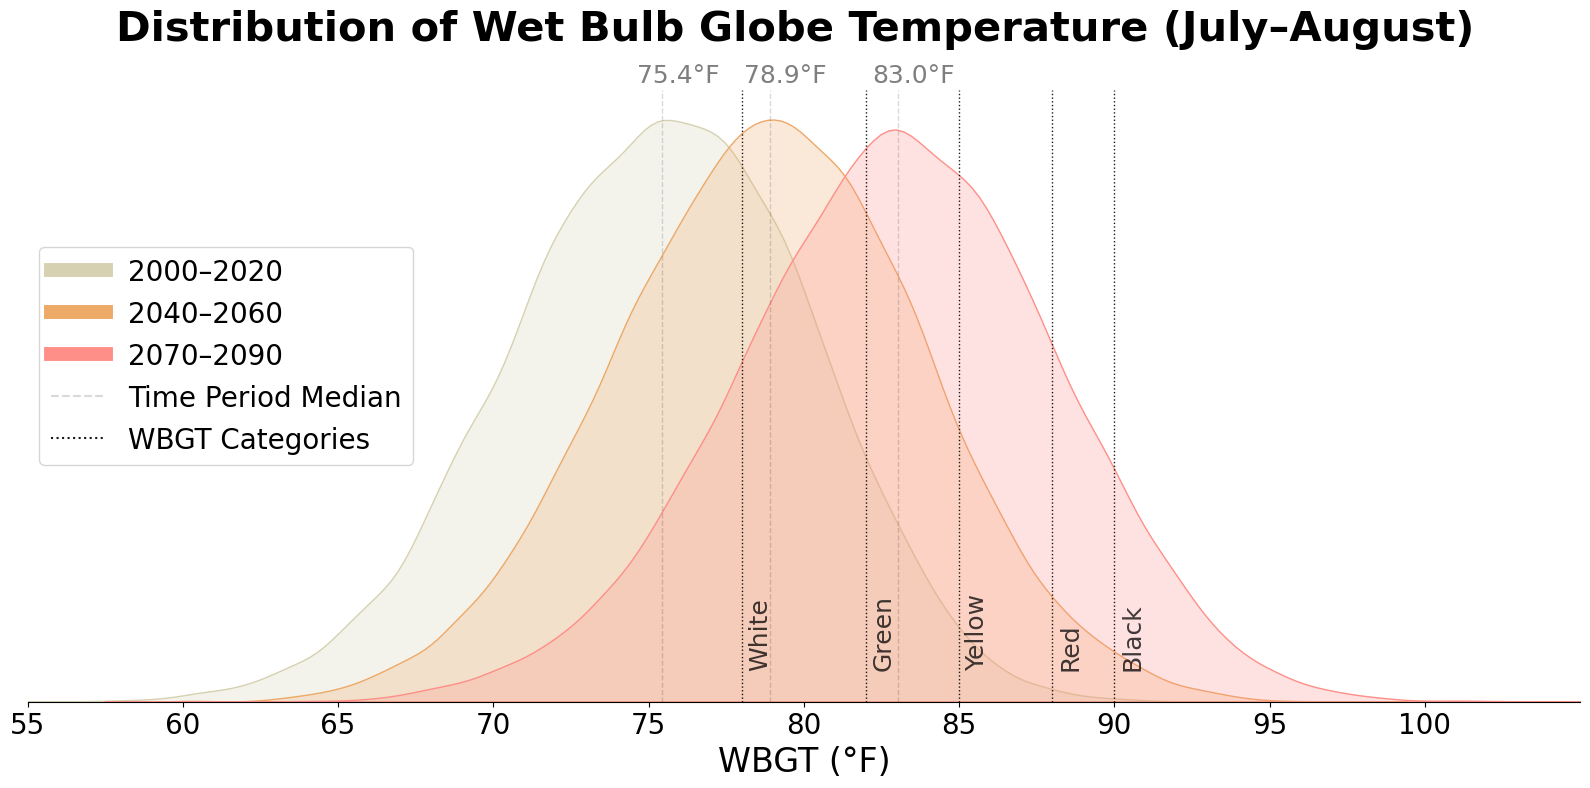

In [4]:
# plot WBGT values
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib import font_manager

font_path = '<font_path>/font.tff'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
fontsize = 20
            
if len(yrs_fut2) > 0:
    colors = ['#D6D1B1', '#eda968', '#fe8f88']
else:
    colors = ['#52bbaf', '#e9c46a']

# bin width
bw = 1

# set xticks, using min/max values of data as guiding limits; round to nearest 'round_to' value
round_to = 5
xtick_min = np.around(np.min(WBGT_df['wbgt']) / round_to, decimals=0) * round_to
xtick_max =  np.around(np.max(WBGT_df['wbgt']) / round_to, decimals=0) * round_to
    
ymax_list = []

wbgt_median_text_voffset = 0.085  # adjust to move wbgt median label text down (lower #) or up (higher #)
wbgt_threshold_text_voffset = 0.005  # adjust to move wbgt-threshold label text down (lower #) or up (higher #)

fig, ax = plt.subplots(1, 1, figsize=(16, 8))  # (width, height) of figure

# isolate each time period and plot
for c in np.arange(len(colors)):  # number of colors corresponds with number of time periods
    if c == 0:
        wbgt = WBGT_df[(WBGT_df['time'] >= f'{yrs_base[0]}-01-01') & (WBGT_df['time'] <= f'{yrs_base[-1]}-12-31')] 
        palette = 'Blues'
    elif c == 1:
        wbgt = WBGT_df[(WBGT_df['time'] >= f'{yrs_fut[0]}-01-01') & (WBGT_df['time'] <= f'{yrs_fut[-1]}-12-31')]
        palette = 'Reds'
    elif c == 2:
        wbgt = WBGT_df[(WBGT_df['time'] >= f'{yrs_fut2[0]}-01-01') & (WBGT_df['time'] <= f'{yrs_fut2[-1]}-12-31')]
        palette = 'Greys'
    else:
        print('Error! Number of colors does not correspond to the number of time periods!')
       
    if plot_method == 'each':  # plot each model separately
        dis = sns.kdeplot(wbgt, x=wbgt['wbgt'], hue=wbgt['model'], ax=ax, fill=True, palette=palette, alpha=0.05)
        ymax_list = np.append(ymax_list, ax.get_ylim()[1])
    elif plot_method == 'all':  # plot all model data as one
        dis = sns.kdeplot(wbgt, x=wbgt['wbgt'], color=colors[c], ax=ax, fill=True)
    else:
        print('Error! Plot_method should be "each" or "all"')

    # plot median for each time period
    wbgt_median = np.median(wbgt['wbgt'])
    ax.axvline(x=wbgt_median, color='k', ls='--', lw=1, alpha=0.15)
    ax.text(wbgt_median + 0.5, wbgt_median_text_voffset, f'{np.round(wbgt_median, 1)}\u00B0{temp_units2plot}', alpha=0.5, fontsize=fontsize - 2, ha='center') #rotation=90

    ymax_list = np.append(ymax_list, ax.get_ylim()[1])

# add WGBT category vertical lines
for k,v in wbgt_thresholds.items():
    ax.axvline(x=v, color='k', ls=':', lw=1, alpha=0.9)
    ax.text(v + 0.2, wbgt_threshold_text_voffset, k, alpha=0.75, rotation=90, fontsize=fontsize - 2)
    
#ax.set_ylim((0, 0.085))
ax.set_ylim((0, np.max(ymax_list)))

ax.set_xlim((xtick_min, xtick_max))
ax.set_xticks(np.arange(xtick_min, xtick_max, round_to))
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.xticks(np.arange(xtick_min, xtick_max, round_to), fontsize=fontsize)
plt.xlabel(f'WBGT (\u00B0{temp_units2plot})', fontsize=fontsize + 4)
plt.ylabel('')

if len(months2include) == 12:
    fig.suptitle('Distribution of Wet Bulb Globe Temperature', fontsize=fontsize + 10, weight='bold')
else:
    fig.suptitle('Distribution of Wet Bulb Globe Temperature ({}\u2013{})'.format(list(months2include.keys())[0], list(months2include.keys())[-1]), 
                 fontsize=fontsize + 10, weight='bold')

# build legend
legend_elements = []
for i in np.arange(len(colors)):
    if i == 0:
        legend_label = f'{yrs_base[0]}\u2013{yrs_base[-1]}'
    elif i == 1:
        legend_label = f'{yrs_fut[0]}\u2013{yrs_fut[-1]}'
    elif i == 2:
        legend_label = f'{yrs_fut2[0]}\u2013{yrs_fut2[-1]}'
    legend_elements.append(Line2D([0], [0], color=colors[i], lw=10, label=legend_label))

legend_elements.append(Line2D([0], [0], color=k, linestyle='--', alpha=0.15, label='Time Period Median'))
legend_elements.append(Line2D([0], [0], color=k, linestyle=':', alpha=0.9, label='WBGT Categories'))
fig.legend(handles=legend_elements, bbox_to_anchor=(0.27, 0.7), fontsize=fontsize)  # (horizontal, vertical) adjustment from ll corner
fig.subplots_adjust(wspace=0, hspace=0)
fig.tight_layout()

if plot_method == 'all':
    plt.savefig(f'{save_path}/{loc}_wbgt_kdeplot_ensemble_{season}.png')
elif plot_method == 'each':
    plt.savefig(f'{save_path}/{loc}_wbgt_kdeplot_models_{season}.png')
else:
    print('Error! Plot method not recognized to properly save plot.')

In [35]:
# calculate annual average number of days in each WBGT category for each time period

# function to calculate sum of days in each WBGT category for input data
def calc_days_in_WBGT_cat(data_series, wbgt_cats_dict):
    days_in_wbgt_cat_dict = {}
    wbgt_cats = list(wbgt_cats_dict.keys())
    wbgt_thresholds = list(wbgt_cats_dict.values())
    
    for i in np.arange(0, len(wbgt_cats)):
        if i != (len(wbgt_cats) - 1):
            days_in_wbgt_cat_dict[wbgt_cats[i]] = sum((data_series >= wbgt_thresholds[i]) & (data_series < wbgt_thresholds[i+1]))
        else: 
            days_in_wbgt_cat_dict[wbgt_cats[i]] = sum(data_series >= wbgt_thresholds[i])
            
    return days_in_wbgt_cat_dict

# select variable data column for specific time period (base and future)
w_base = WBGT_df[(WBGT_df['time'] >= f'{yrs_base[0]}-01-01') & (WBGT_df['time'] <= f'{yrs_base[-1]}-12-31')].wbgt
w_fut = WBGT_df[(WBGT_df['time'] >= f'{yrs_fut[0]}-01-01') & (WBGT_df['time'] <= f'{yrs_fut[-1]}-12-31')].wbgt
w_fut2 = WBGT_df[(WBGT_df['time'] >= f'{yrs_fut2[0]}-01-01') & (WBGT_df['time'] <= f'{yrs_fut2[-1]}-12-31')].wbgt

base_wbgt_cat_days = calc_days_in_WBGT_cat(w_base, wbgt_thresholds)
fut_wbgt_cat_days = calc_days_in_WBGT_cat(w_fut, wbgt_thresholds)
fut2_wbgt_cat_days = calc_days_in_WBGT_cat(w_fut2, wbgt_thresholds)

# divide counts by # of models and # of years in time period (to get annual average)
annual_avg_base_days = {k: np.round((v / len(models) / len(yrs_base)), 1) for k, v in base_wbgt_cat_days.items()}
annual_avg_fut_days = {k: np.round((v / len(models) / len(yrs_fut)), 1) for k, v in fut_wbgt_cat_days.items()}
annual_avg_fut2_days = {k: np.round((v / len(models) / len(yrs_fut2)), 1) for k, v in fut2_wbgt_cat_days.items()}

print(annual_avg_base_days)
print(annual_avg_fut_days)
print(annual_avg_fut2_days)


{'White': np.float64(13.7), 'Green': np.float64(3.8), 'Yellow': np.float64(0.8), 'Red': np.float64(0.1), 'Black': np.float64(0.0)}
{'White': np.float64(19.1), 'Green': np.float64(9.9), 'Yellow': np.float64(4.5), 'Red': np.float64(1.2), 'Black': np.float64(0.7)}
{'White': np.float64(15.6), 'Green': np.float64(14.3), 'Yellow': np.float64(11.7), 'Red': np.float64(4.9), 'Black': np.float64(5.2)}
